# Bab 1 — Exploratory Data Analysis (EDA)

Notebook ini merangkum **Bab 1** buku *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck, 2nd ed.).

**Exploratory Data Analysis (EDA)** adalah langkah pertama dalam setiap proyek data science: kita *melihat*, *meringkas*, dan *memvisualisasikan* data sebelum membuat model. Istilah ini dipopulerkan oleh John Tukey (1977) dalam bukunya *Exploratory Data Analysis*.

Isi notebook:
1. Elemen data terstruktur
2. Data rektangular (DataFrame pandas)
3. Estimasi lokasi (mean, median, dll.)
4. Estimasi variabilitas (std, IQR, MAD)
5. Mengeksplorasi distribusi data
6. Data biner & kategorikal
7. Korelasi
8. Mengeksplorasi dua variabel atau lebih

## 0. Setup

Dataset yang dipakai adalah dataset resmi buku ini (repo GitHub `gedeck/practical-statistics-for-data-scientists`). Fungsi `load()` di bawah akan mencari file di folder lokal `data/` terlebih dahulu; kalau tidak ada, file diunduh langsung dari GitHub (butuh internet).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style='whitegrid')

DATA_URL = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

def load(name, **kwargs):
    local = Path('data') / name
    source = local if local.exists() else DATA_URL + name
    return pd.read_csv(source, **kwargs)

## 1. Elemen Data Terstruktur

Data mentah (teks, klik, sensor, gambar) biasanya **tidak terstruktur**. Tugas pertama data scientist adalah mengubahnya menjadi **data terstruktur**. Ada dua tipe dasar data terstruktur:

| Tipe | Definisi | Contoh |
|---|---|---|
| **Numerik – kontinu** | Bisa bernilai berapa pun dalam suatu interval | kecepatan angin, durasi |
| **Numerik – diskrit** | Hanya bilangan bulat (hasil hitungan) | jumlah kejadian |
| **Kategorikal** | Hanya bisa bernilai dari himpunan tertentu | jenis TV, nama negara |
| **Biner** | Kategorikal dengan 2 kategori saja | 0/1, ya/tidak |
| **Ordinal** | Kategorikal yang punya urutan | rating 1–5, level pendidikan |

**Kenapa tipe data penting?** Tipe data menentukan jenis visualisasi, analisis, dan model yang cocok. Di pandas, tipe data juga memengaruhi efisiensi memori dan cara library (misal `statsmodels`, `sklearn`) memperlakukan kolom tersebut.

In [2]:
df_tipe = pd.DataFrame({
    'durasi_menit': [12.5, 3.2, 45.0, 7.8],          # numerik kontinu
    'jumlah_klik': [3, 0, 12, 5],                    # numerik diskrit
    'negara': ['ID', 'MY', 'ID', 'SG'],              # kategorikal
    'beli': [True, False, True, False],              # biner
    'rating': ['rendah', 'tinggi', 'sedang', 'tinggi'] # ordinal
})

# Ubah ke tipe kategorikal pandas
df_tipe['negara'] = df_tipe['negara'].astype('category')
df_tipe['rating'] = pd.Categorical(df_tipe['rating'],
                                   categories=['rendah', 'sedang', 'tinggi'],
                                   ordered=True)
print(df_tipe.dtypes)

# Karena ordinal, kita bisa membandingkan urutan
df_tipe[df_tipe['rating'] >= 'sedang']

durasi_menit     float64
jumlah_klik        int64
negara          category
beli                bool
rating          category
dtype: object


,durasi_menit,jumlah_klik,negara,beli,rating
1,3.2,0,MY,False,tinggi
2,45.0,12,ID,True,sedang
3,7.8,5,SG,False,tinggi


## 2. Data Rektangular

**Data rektangular** adalah bentuk data paling umum dalam analisis: sebuah tabel 2 dimensi di mana **baris = record (observasi)** dan **kolom = feature (variabel)**.

Istilah penting:
- **Data frame** — struktur data rektangular (seperti spreadsheet). Di Python disediakan oleh library **pandas**.
- **Feature** — kolom dalam tabel (sinonim: atribut, input, predictor, variable).
- **Outcome** — variabel yang ingin diprediksi (sinonim: dependent variable, response, target).
- **Record** — satu baris (sinonim: case, example, instance, observation).

### Apa itu pandas?
**pandas** adalah library Python untuk manipulasi dan analisis data tabular. Dua struktur utamanya:
- `pd.Series` — array 1 dimensi berlabel (satu kolom).
- `pd.DataFrame` — tabel 2 dimensi berlabel (kumpulan Series yang berbagi **index**).

Setiap DataFrame punya **index** (label baris). Secara default index berupa bilangan bulat 0, 1, 2, ..., tapi bisa diganti dengan kolom lain (misalnya tanggal).

In [3]:
# Membuat Series dan DataFrame dari nol
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'], name='nilai')
print(s, end='\n\n')

df = pd.DataFrame({'nama': ['Ani', 'Budi', 'Citra'],
                   'umur': [23, 31, 27],
                   'kota': ['Jakarta', 'Bandung', 'Surabaya']})
df

a    10
b    20
c    30
Name: nilai, dtype: int64



,nama,umur,kota
0,Ani,23,Jakarta
1,Budi,31,Bandung
2,Citra,27,Surabaya


In [4]:
# Operasi dasar pandas
print('shape  :', df.shape)            # (jumlah baris, jumlah kolom)
print('kolom  :', list(df.columns))
print('rata2 umur:', df['umur'].mean())

# Seleksi baris dengan kondisi (boolean indexing)
print(df[df['umur'] > 25])

# loc = berdasarkan label, iloc = berdasarkan posisi
print(df.loc[0, 'nama'], '|', df.iloc[1, 2])

# Menjadikan kolom 'nama' sebagai index
df.set_index('nama')

shape  : (3, 3)
kolom  : ['nama', 'umur', 'kota']
rata2 umur: 27.0
    nama  umur      kota
1   Budi    31   Bandung
2  Citra    27  Surabaya
Ani | Bandung


,umur,kota
nama,,
Ani,23,Jakarta
Budi,31,Bandung
Citra,27,Surabaya


### Dataset contoh: `state.csv`
Dataset ini berisi populasi dan tingkat pembunuhan (murder rate, per 100.000 penduduk) di 50 negara bagian AS. Kita akan memakainya untuk estimasi lokasi & variabilitas.

> **Data non-rektangular**: selain tabel, ada juga *time series* (data berurutan waktu), *spatial data* (data lokasi), dan *graph/network data* (relasi antar objek). Buku ini fokus pada data rektangular.

In [5]:
state = load('state.csv')
print(state.shape)
state.head(8)

(50, 4)


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


In [6]:
state.info()
state.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


## 3. Estimasi Lokasi (Estimates of Location)

**Estimasi lokasi** (*central tendency*) menjawab pertanyaan: *di mana letak nilai tipikal dari data?*

| Estimator | Definisi | Rumus |
|---|---|---|
| **Mean** (rata-rata) | Jumlah semua nilai dibagi banyaknya nilai | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ |
| **Weighted mean** | Rata-rata di mana tiap nilai dikalikan bobot $w_i$ | $\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$ |
| **Trimmed mean** | Mean setelah membuang $p$ nilai terkecil dan terbesar | $\bar{x}_{trim} = \frac{1}{n-2p}\sum_{i=p+1}^{n-p} x_{(i)}$ |
| **Median** | Nilai tengah setelah data diurutkan (persentil ke-50) | — |
| **Weighted median** | Nilai di mana jumlah bobot di bawah & di atasnya sama | — |

Konsep penting:
- **Outlier** — nilai yang sangat berbeda dari sebagian besar data.
- **Robust** — estimator yang *tidak sensitif* terhadap outlier. Median dan trimmed mean bersifat robust; mean **tidak** robust.

Contoh intuisi: rata-rata pendapatan di sebuah kafe melonjak drastis kalau Bill Gates masuk, tetapi median-nya hampir tidak berubah.

In [7]:
print('Mean populasi        :', state['Population'].mean())
print('Trimmed mean (10%)   :', stats.trim_mean(state['Population'], 0.1))
print('Median populasi      :', state['Population'].median())

Mean populasi        : 6162876.3
Trimmed mean (10%)   : 4783697.125
Median populasi      : 4436369.5


Mean > trimmed mean > median. Artinya ada beberapa negara bagian dengan populasi sangat besar (California, Texas) yang "menarik" mean ke atas — distribusinya **miring ke kanan** (*right-skewed*).

### Weighted mean & weighted median
Untuk menghitung murder rate rata-rata **seluruh AS**, kita tidak boleh sekadar merata-ratakan murder rate tiap state, karena state kecil akan punya pengaruh yang sama dengan state besar. Solusinya: beri **bobot = populasi**.

In [8]:
def weighted_median(values, weights):
    """Nilai pertama di mana bobot kumulatif >= setengah total bobot."""
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights)[order]
    cum_w = np.cumsum(w)
    return v[np.searchsorted(cum_w, 0.5 * cum_w[-1])]

print('Mean murder rate (biasa)   :', state['Murder.Rate'].mean())
print('Weighted mean murder rate  :', np.average(state['Murder.Rate'], weights=state['Population']))
print('Weighted median murder rate:', weighted_median(state['Murder.Rate'], state['Population']))

Mean murder rate (biasa)   : 4.066
Weighted mean murder rate  : 4.445833981123393
Weighted median murder rate: 4.4


In [9]:
# Demonstrasi robustness: tambahkan satu outlier ekstrem
data = np.array([3, 4, 5, 5, 6, 7, 8])
data_outlier = np.append(data, 1000)

for label, d in [('tanpa outlier', data), ('dengan outlier', data_outlier)]:
    print(f'{label:15s} mean={d.mean():8.2f}  median={np.median(d):5.2f}  '
          f'trimmed(10%)={stats.trim_mean(d, 0.1):6.2f}')

tanpa outlier   mean=    5.43  median= 5.00  trimmed(10%)=  5.43
dengan outlier  mean=  129.75  median= 5.50  trimmed(10%)=129.75


## 4. Estimasi Variabilitas (Estimates of Variability)

**Variabilitas** (*dispersion*) mengukur seberapa **tersebar** atau **rapat** nilai-nilai data. Dua dataset bisa punya mean sama tapi sebaran yang sangat berbeda.

| Estimator | Definisi | Rumus |
|---|---|---|
| **Deviasi / residual** | Selisih nilai observasi dengan estimasi lokasi | $x_i - \bar{x}$ |
| **Variance** | Rata-rata kuadrat deviasi | $s^2 = \frac{\sum (x_i-\bar{x})^2}{n-1}$ |
| **Standard deviation** | Akar kuadrat variance (satuan sama dengan data) | $s = \sqrt{s^2}$ |
| **Mean absolute deviation** | Rata-rata nilai absolut deviasi | $\frac{1}{n}\sum \lvert x_i-\bar{x}\rvert$ |
| **Median absolute deviation (MAD)** | Median dari nilai absolut deviasi terhadap median | $\text{median}(\lvert x_i - m\rvert)$ |
| **Range** | Nilai maksimum − minimum | $x_{max} - x_{min}$ |
| **Percentile** | Nilai di mana P% data berada di bawahnya | — |
| **IQR** | Selisih persentil ke-75 dan ke-25 | $Q_3 - Q_1$ |

**Kenapa dibagi $n-1$, bukan $n$?** Karena kita memakai $\bar{x}$ yang dihitung dari data itu sendiri, satu *degree of freedom* hilang. Pembagian $n-1$ membuat variance menjadi estimator **unbiased** untuk variance populasi.

Standard deviation dan range **sensitif terhadap outlier**; MAD dan IQR bersifat **robust**.

In [10]:
pop = state['Population']

print('Standard deviation :', pop.std())      # pandas default ddof=1 (n-1)
print('Variance           :', pop.var())
print('Mean abs deviation :', (pop - pop.mean()).abs().mean())
print('IQR                :', pop.quantile(0.75) - pop.quantile(0.25))
print('MAD (raw)          :', stats.median_abs_deviation(pop))
# scale='normal' mengalikan 1.4826 sehingga MAD sebanding dengan std untuk data normal
print('MAD (scaled)       :', stats.median_abs_deviation(pop, scale='normal'))
print('Range              :', pop.max() - pop.min())

Standard deviation : 6848235.347401142
Variance           : 46898327373394.445
Mean abs deviation : 4450933.356000001
IQR                : 4847308.0
MAD (raw)          : 2596702.0
MAD (scaled)       : 3849876.1459979336
Range              : 36690330


## 5. Mengeksplorasi Distribusi Data

Satu angka ringkasan (mean, std) tidak cukup. Kita perlu melihat **bentuk distribusi** secara keseluruhan.

- **Boxplot** — plot yang diperkenalkan Tukey untuk memvisualisasikan distribusi berdasarkan persentil. Kotak = Q1 sampai Q3 (IQR), garis di dalam = median, *whiskers* = sampai 1.5 × IQR, titik di luar = potensi outlier.
- **Frequency table** — tabel jumlah data yang jatuh ke dalam tiap interval (*bin*).
- **Histogram** — plot dari frequency table: sumbu x = bin, sumbu y = frekuensi.
- **Density plot** — versi halus dari histogram, biasanya dihitung dengan *kernel density estimate* (KDE).

In [11]:
# Percentile murder rate
state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64

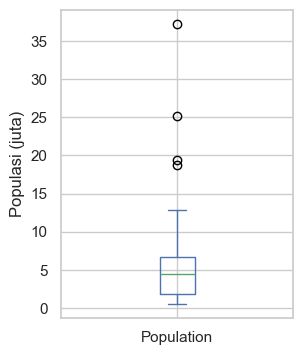

In [12]:
ax = (state['Population'] / 1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Populasi (juta)')
plt.show()

In [13]:
# Frequency table: bagi populasi ke 10 bin dengan lebar sama
binned_pop = pd.cut(state['Population'], 10)
freq_table = binned_pop.value_counts().sort_index()
freq_table

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64

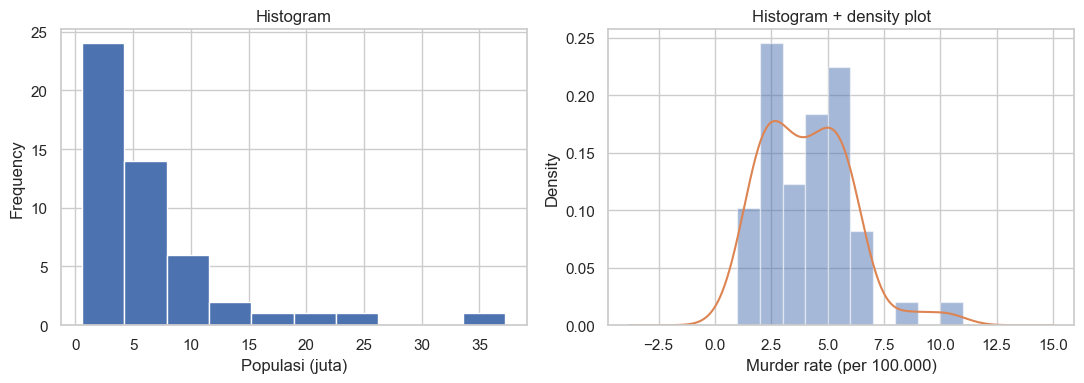

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

(state['Population'] / 1_000_000).plot.hist(bins=10, ax=axes[0], edgecolor='white')
axes[0].set_xlabel('Populasi (juta)')
axes[0].set_title('Histogram')

state['Murder.Rate'].plot.hist(density=True, bins=range(1, 12), ax=axes[1],
                               alpha=0.5, edgecolor='white')
state['Murder.Rate'].plot.density(ax=axes[1])
axes[1].set_xlabel('Murder rate (per 100.000)')
axes[1].set_title('Histogram + density plot')
plt.tight_layout()
plt.show()

> **Skewness** mengukur kemiringan distribusi (miring ke kiri/kanan), sedangkan **kurtosis** mengukur seberapa "berat" ekor distribusi (kecenderungan punya nilai ekstrem).

In [15]:
print('Skewness populasi :', state['Population'].skew())
print('Kurtosis populasi :', state['Population'].kurt())

Skewness populasi : 2.6426346412748765
Kurtosis populasi : 8.722114728161502


## 6. Mengeksplorasi Data Biner & Kategorikal

Untuk data kategorikal, ringkasannya sederhana: **proporsi** atau **persentase** tiap kategori.

- **Mode (modus)** — kategori atau nilai yang paling sering muncul.
- **Expected value** — rata-rata tertimbang dari nilai-nilai kategori, dengan bobot = probabilitasnya: $EV = \sum_i p_i \cdot v_i$.
- **Bar chart** — frekuensi/proporsi tiap kategori sebagai batang.
- **Pie chart** — proporsi sebagai irisan lingkaran (umumnya kurang informatif dibanding bar chart).

Contoh data: `dfw_airline.csv` berisi persentase penyebab keterlambatan penerbangan di bandara Dallas/Fort Worth.

In [16]:
dfw = load('dfw_airline.csv')
print(dfw)
print('Persentase:')
print((100 * dfw / dfw.values.sum()).round(2))

    Carrier      ATC   Weather  Security    Inbound
0  64263.16  84856.5  11235.42    343.15  118427.82
Persentase:
   Carrier   ATC  Weather  Security  Inbound
0    23.02  30.4     4.03      0.12    42.43


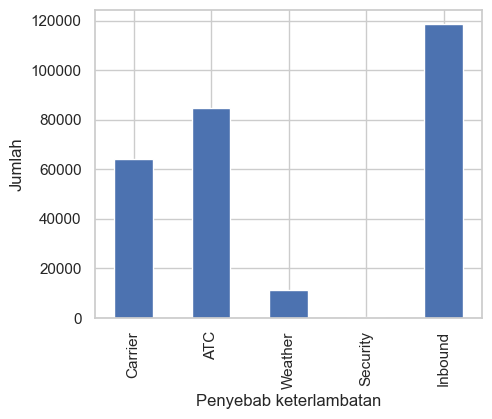

In [17]:
ax = dfw.transpose().plot.bar(figsize=(5, 4), legend=False)
ax.set_xlabel('Penyebab keterlambatan')
ax.set_ylabel('Jumlah')
plt.show()

In [18]:
# Mode
print('Mode penyebab delay:', dfw.transpose().idxmax().iloc[0])

# Expected value: contoh penawaran cloud service
# 5% pelanggan membeli paket $300/bulan, 15% paket $50/bulan, 80% tidak membeli
prob  = np.array([0.05, 0.15, 0.80])
value = np.array([300, 50, 0])
print('Expected value per pelanggan: $', (prob * value).sum())

Mode penyebab delay: Inbound
Expected value per pelanggan: $ 22.5


## 7. Korelasi

**Korelasi** mengukur sejauh mana dua variabel numerik bergerak bersama. Variabel X dan Y berkorelasi **positif** jika nilai X yang tinggi cenderung disertai Y yang tinggi, dan **negatif** jika X tinggi cenderung disertai Y rendah.

**Koefisien korelasi Pearson**:
$$r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{(n-1)\,s_x\,s_y}$$

Nilainya selalu antara −1 (negatif sempurna) dan +1 (positif sempurna); 0 berarti tidak ada korelasi **linear**.

Istilah terkait:
- **Correlation matrix** — tabel korelasi antar semua pasangan variabel.
- **Scatterplot** — plot titik dengan X di sumbu horizontal dan Y di sumbu vertikal.
- **Spearman's rho / Kendall's tau** — korelasi berbasis *ranking*, lebih robust terhadap outlier dan bisa menangkap hubungan monoton non-linear.

Contoh: return harian saham-saham S&P 500.

In [19]:
sp500_px = load('sp500_data.csv.gz', index_col=0)
sp500_sym = load('sp500_sectors.csv')

# Ambil saham sektor telekomunikasi sejak Juli 2012
telecom_symbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecom_symbols]
telecom.corr()

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


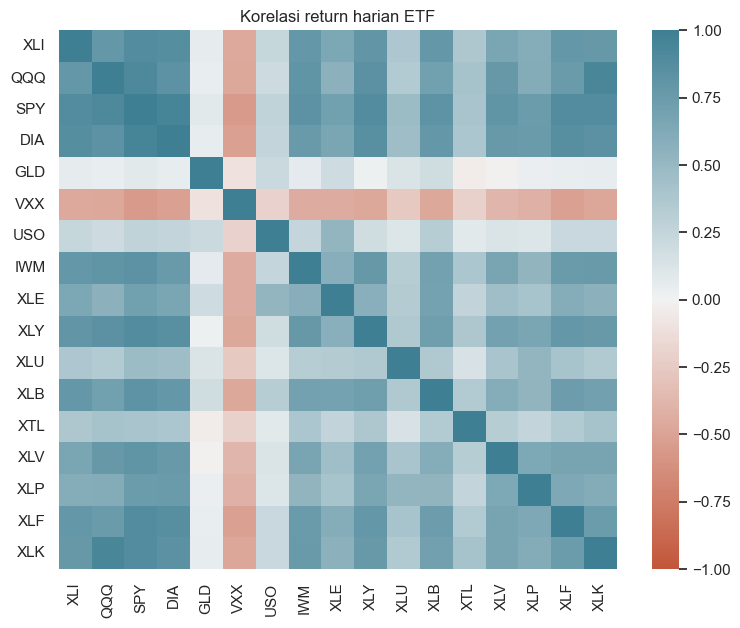

In [20]:
# Correlation matrix untuk ETF, divisualisasikan sebagai heatmap
etf_symbols = sp500_sym[sp500_sym['sector'] == 'etf']['symbol']
etfs = sp500_px.loc[sp500_px.index > '2012-07-01', etf_symbols]

plt.figure(figsize=(9, 7))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1, cmap=sns.diverging_palette(20, 220, as_cmap=True))
plt.title('Korelasi return harian ETF')
plt.show()

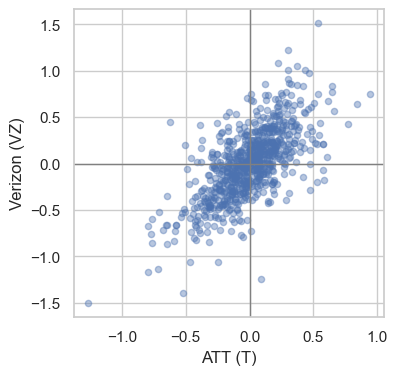

Pearson : 0.6776124610128053
Spearman: 0.6649847837751102
Kendall : 0.4901805357574282


In [21]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), alpha=0.4)
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)
plt.show()

print('Pearson :', telecom['T'].corr(telecom['VZ']))
print('Spearman:', telecom['T'].corr(telecom['VZ'], method='spearman'))
print('Kendall :', telecom['T'].corr(telecom['VZ'], method='kendall'))

In [22]:
# Korelasi hanya menangkap hubungan LINEAR: contoh hubungan kuadratik sempurna
x = np.linspace(-3, 3, 100)
y = x ** 2
print('Pearson r untuk y = x^2 :', np.corrcoef(x, y)[0, 1].round(4))

Pearson r untuk y = x^2 : 0.0


## 8. Mengeksplorasi Dua Variabel atau Lebih

Mean dan variance adalah analisis **univariat** (satu variabel). Korelasi adalah analisis **bivariat** (dua variabel). Analisis lebih dari dua variabel disebut **multivariat**.

| Teknik | Kapan dipakai |
|---|---|
| **Hexagonal binning** | Dua variabel numerik dengan data sangat banyak (scatterplot jadi terlalu padat) |
| **Contour plot** | Dua variabel numerik, menampilkan kepadatan seperti peta topografi |
| **Contingency table** | Dua variabel kategorikal (tabel frekuensi silang) |
| **Boxplot / violin plot per grup** | Satu variabel numerik vs satu variabel kategorikal |
| **Faceting / conditioning** | Menambahkan variabel ketiga dengan membuat panel terpisah per grup |

### 8.1 Hexagonal binning & contour
Data `kc_tax.csv.gz`: nilai taksiran pajak rumah vs luas bangunan di King County, Washington.

(432693, 3)


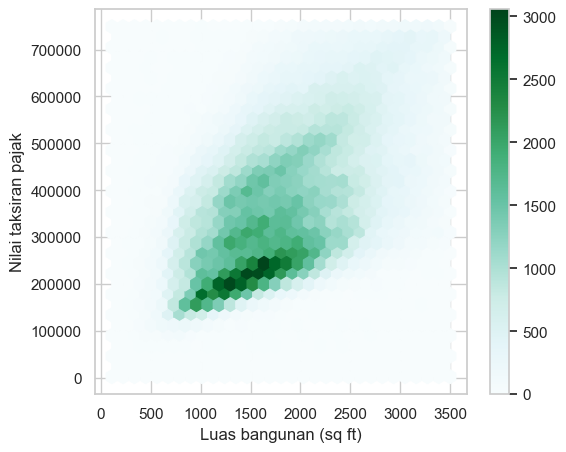

In [23]:
kc_tax = load('kc_tax.csv.gz')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(6, 5))
ax.set_xlabel('Luas bangunan (sq ft)')
ax.set_ylabel('Nilai taksiran pajak')
plt.show()

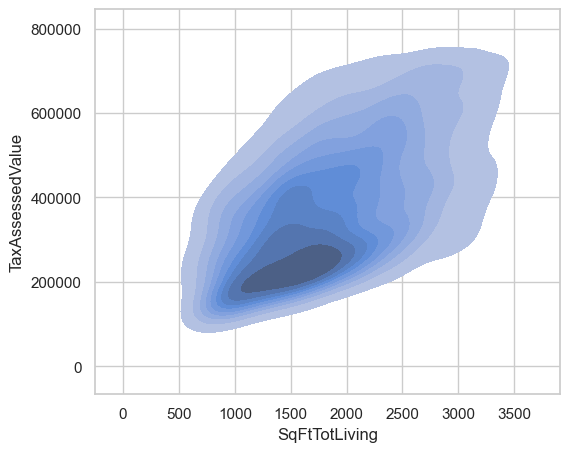

In [24]:
# Contour (KDE 2D) - pakai sampel agar cepat
sample = kc_tax0.sample(10_000, random_state=1)
plt.figure(figsize=(6, 5))
sns.kdeplot(data=sample, x='SqFtTotLiving', y='TaxAssessedValue', fill=True, levels=10)
plt.show()

### 8.2 Dua variabel kategorikal — contingency table
Data `lc_loans.csv` (Lending Club): *grade* pinjaman (A = terbaik, G = terburuk) vs status pinjaman.

In [25]:
lc_loans = load('lc_loans.csv')

# Jumlah absolut
crosstab = pd.crosstab(lc_loans['grade'], lc_loans['status'], margins=True)
print(crosstab, end='\n\n')

# Proporsi per baris (tiap grade dijumlahkan = 1)
pd.crosstab(lc_loans['grade'], lc_loans['status'], normalize='index').round(3)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961



status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,0.022,0.690,0.282,0.006
B,0.040,0.709,0.235,0.016
C,0.050,0.736,0.191,0.023
D,0.067,0.717,0.184,0.031
E,0.082,0.708,0.171,0.039
F,0.118,0.654,0.180,0.047
G,0.126,0.614,0.198,0.061


### 8.3 Data kategorikal & numerik — boxplot dan violin plot
Data `airline_stats.csv`: persentase penerbangan yang terlambat karena maskapai, per maskapai.

**Violin plot** adalah pengembangan boxplot yang juga menampilkan *density* sehingga bentuk distribusi terlihat (misalnya distribusi bimodal).

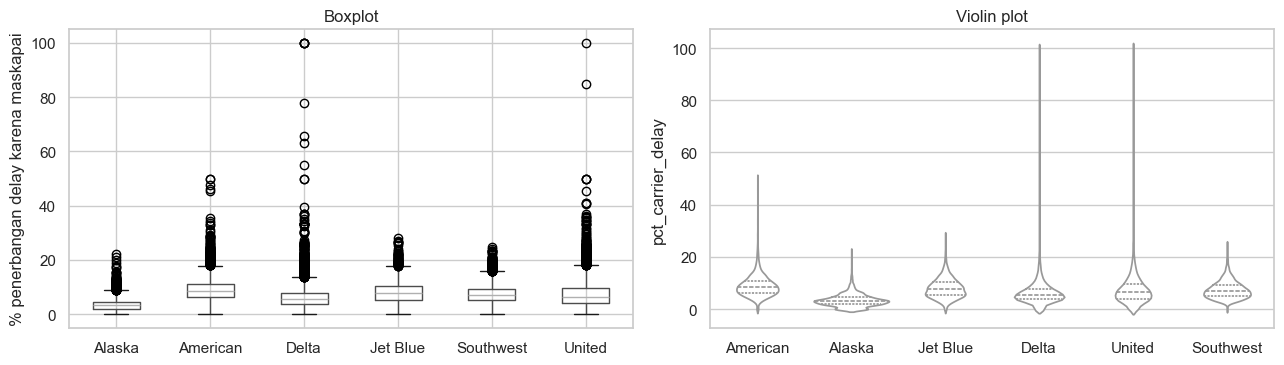

In [26]:
airline_stats = load('airline_stats.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
airline_stats.boxplot(by='airline', column='pct_carrier_delay', ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('% penerbangan delay karena maskapai')
axes[0].set_title('Boxplot')

sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               inner='quartile', color='white', ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_title('Violin plot')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 8.4 Visualisasi banyak variabel — faceting (conditioning)
Kita bisa menambah variabel ketiga dengan membuat **panel terpisah** untuk tiap nilai variabel tersebut. Di bawah ini hexbin luas rumah vs nilai pajak, dipisah per **kode pos**. Terlihat bahwa hubungan luas–harga berbeda antar lokasi.

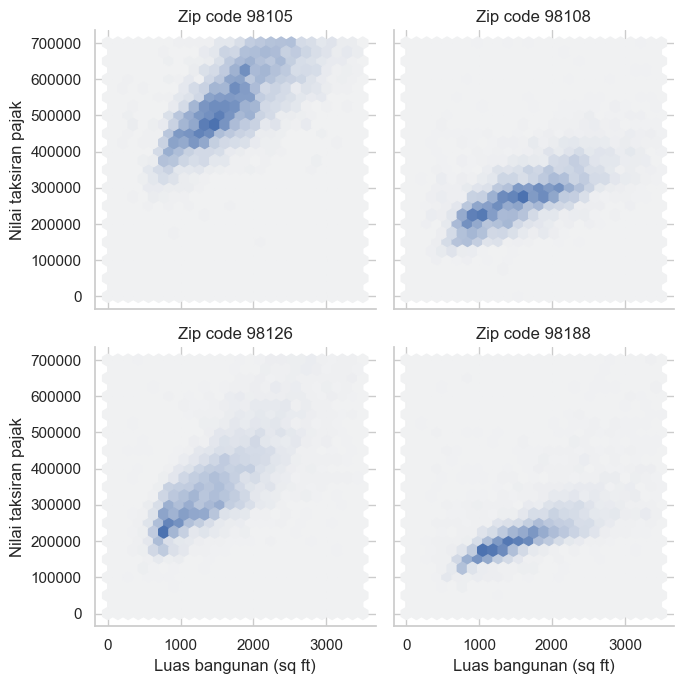

In [27]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2, height=3.5)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue', extent=[0, 3500, 0, 700000])
g.set_axis_labels('Luas bangunan (sq ft)', 'Nilai taksiran pajak')
g.set_titles('Zip code {col_name:.0f}')
plt.show()

## Rangkuman Bab 1

- EDA adalah fondasi setiap proyek data: selalu **lihat datanya** sebelum membuat model.
- Kenali **tipe data** (numerik kontinu/diskrit, kategorikal, biner, ordinal) karena menentukan analisis yang cocok.
- **Lokasi**: mean mudah dihitung tapi sensitif outlier; median & trimmed mean lebih **robust**. Gunakan **weighted** mean/median bila tiap observasi punya bobot berbeda.
- **Variabilitas**: std & variance paling umum; IQR & MAD lebih robust.
- **Distribusi**: gunakan boxplot, histogram, dan density plot.
- **Kategorikal**: proporsi, mode, expected value, bar chart.
- **Korelasi** hanya mengukur hubungan **linear**; selalu cek dengan scatterplot.
- Untuk 2+ variabel: hexbin, contour, contingency table, boxplot/violin per grup, dan faceting.